In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

1. LOAD AND PREPARE DATA

In [ ]:
df = pd.read_csv('antibiotic_DDD.csv')

In [ ]:
# Display basic inforamtion about dataset
print("dataset.shape:", df.shape)
print(df.head)

dataset.shape: (416, 34)
<bound method NDFrame.head of     IndicatorCode                                          Indicator  \
0     GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
1     GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
2     GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
3     GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
4     GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
..            ...                                                ...   
411   GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
412   GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
413   GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
414   GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   
415   GLASSAMC_TC  Total use of antibacterials expressed as DDD p...   

    ValueType ParentLocationCode         ParentLocation Location type  \
0     n

In [ ]:
# check datatype
print(df.dtypes)

IndicatorCode                  object
Indicator                      object
ValueType                      object
ParentLocationCode             object
ParentLocation                 object
Location type                  object
SpatialDimValueCode            object
Location                       object
Period type                    object
Period                          int64
IsLatestYear                     bool
Dim1 type                     float64
Dim1                          float64
Dim1ValueCode                 float64
Dim2 type                     float64
Dim2                          float64
Dim2ValueCode                 float64
Dim3 type                     float64
Dim3                          float64
Dim3ValueCode                 float64
DataSourceDimValueCode        float64
DataSource                    float64
FactValueNumericPrefix        float64
FactValueNumeric              float64
FactValueUoM                  float64
FactValueNumericLowPrefix     float64
FactValueNum

In [ ]:
# check missing values
print(df.isnull().sum())

IndicatorCode                   0
Indicator                       0
ValueType                       0
ParentLocationCode              0
ParentLocation                  0
Location type                   0
SpatialDimValueCode             0
Location                        0
Period type                     0
Period                          0
IsLatestYear                    0
Dim1 type                     416
Dim1                          416
Dim1ValueCode                 416
Dim2 type                     416
Dim2                          416
Dim2ValueCode                 416
Dim3 type                     416
Dim3                          416
Dim3ValueCode                 416
DataSourceDimValueCode        416
DataSource                    416
FactValueNumericPrefix        416
FactValueNumeric                0
FactValueUoM                  416
FactValueNumericLowPrefix     416
FactValueNumericLow           416
FactValueNumericHighPrefix    416
FactValueNumericHigh          416
Value         

In [ ]:
# Basic statistics for the numeric columns
print(df.describe())

            Period  Dim1 type  Dim1  Dim1ValueCode  Dim2 type  Dim2  \
count   416.000000        0.0   0.0            0.0        0.0   0.0   
mean   2019.937500        NaN   NaN            NaN        NaN   NaN   
std       2.241114        NaN   NaN            NaN        NaN   NaN   
min    2016.000000        NaN   NaN            NaN        NaN   NaN   
25%    2018.000000        NaN   NaN            NaN        NaN   NaN   
50%    2020.000000        NaN   NaN            NaN        NaN   NaN   
75%    2022.000000        NaN   NaN            NaN        NaN   NaN   
max    2023.000000        NaN   NaN            NaN        NaN   NaN   

       Dim2ValueCode  Dim3 type  Dim3  Dim3ValueCode  ...  DataSource  \
count            0.0        0.0   0.0            0.0  ...         0.0   
mean             NaN        NaN   NaN            NaN  ...         NaN   
std              NaN        NaN   NaN            NaN  ...         NaN   
min              NaN        NaN   NaN            NaN  ...         Na

In [ ]:
# columns name
print(df.columns)

Index(['IndicatorCode', 'Indicator', 'ValueType', 'ParentLocationCode',
       'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location',
       'Period type', 'Period', 'IsLatestYear', 'Dim1 type', 'Dim1',
       'Dim1ValueCode', 'Dim2 type', 'Dim2', 'Dim2ValueCode', 'Dim3 type',
       'Dim3', 'Dim3ValueCode', 'DataSourceDimValueCode', 'DataSource',
       'FactValueNumericPrefix', 'FactValueNumeric', 'FactValueUoM',
       'FactValueNumericLowPrefix', 'FactValueNumericLow',
       'FactValueNumericHighPrefix', 'FactValueNumericHigh', 'Value',
       'FactValueTranslationID', 'FactComments', 'Language', 'DateModified'],
      dtype='object')


In [ ]:
# Clean data
df_clean = df.dropna(subset=['FactValueNumeric']).copy()
df_clean['Period'] = pd.to_numeric(df_clean['Period'], errors='coerce')
df_clean = df_clean.dropna(subset=['Period'])

df_analysis = df_clean[['Location', 'Period', 'FactValueNumeric', 'ParentLocation']].copy()
df_analysis.columns = ['Country', 'Year', 'DDD_per_1000', 'Region']
df_analysis = df_analysis.reset_index(drop=True)

print("=" * 80)
print("ADVANCED ANTIBIOTIC DDD ANALYSIS")
print("=" * 80)
print(f"Dataset: {df_analysis.shape[0]} observations | {df_analysis['Country'].nunique()} countries | {df_analysis['Region'].nunique()} regions\n")

ADVANCED ANTIBIOTIC DDD ANALYSIS
Dataset: 416 observations | 73 countries | 7 regions



2. CORRELATION ANALYSIS - YEAR VS DDD USAGE

In [ ]:
# Overall correlation
pearson_corr, pearson_p = pearsonr(df_analysis['Year'], df_analysis['DDD_per_1000'])
spearman_corr, spearman_p = spearmanr(df_analysis['Year'], df_analysis['DDD_per_1000'])

print(f"\nGlobal Trend Analysis:")
print(f"  Pearson Correlation: {pearson_corr:.4f} (p-value: {pearson_p:.4e})")
print(f"  Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4e})")
print(f"  Interpretation: {'SIGNIFICANT' if pearson_p < 0.05 else 'NOT SIGNIFICANT'} temporal trend")


Global Trend Analysis:
  Pearson Correlation: -0.0333 (p-value: 4.9862e-01)
  Spearman Correlation: -0.0330 (p-value: 5.0267e-01)
  Interpretation: NOT SIGNIFICANT temporal trend


In [ ]:
# Correlation by region
print(f"\nCorrelation by Region (Year vs DDD Usage):")
regional_correlations = []
for region in df_analysis['Region'].unique():
    region_data = df_analysis[df_analysis['Region'] == region]
    if len(region_data) > 2:
        corr, p_val = pearsonr(region_data['Year'], region_data['DDD_per_1000'])
        regional_correlations.append({
            'Region': region,
            'Correlation': corr,
            'P-Value': p_val,
            'Significant': 'Yes' if p_val < 0.05 else 'No',
            'Observations': len(region_data)
        })

region_corr_df = pd.DataFrame(regional_correlations).sort_values('Correlation', ascending=False)
print(region_corr_df.to_string(index=False))


Correlation by Region (Year vs DDD Usage):
               Region  Correlation  P-Value Significant  Observations
               Global     0.917795 0.259936          No             3
      South-East Asia     0.116899 0.524020          No            32
               Europe    -0.026992 0.666695          No           257
      Western Pacific    -0.115115 0.682890          No            15
             Americas    -0.115712 0.658312          No            17
Eastern Mediterranean    -0.167734 0.328156          No            36
               Africa    -0.324010 0.014847         Yes            56


3. ADVANCED REGIONAL COMPARISON

In [ ]:
# Detailed regional statistics
regional_detailed = df_analysis.groupby('Region')['DDD_per_1000'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('CV', lambda x: (x.std() / x.mean()) * 100)  # Coefficient of Variation
]).round(2)

print(f"\nComprehensive Regional Statistics:")
print(regional_detailed.sort_values('Mean', ascending=False))


Comprehensive Regional Statistics:
                       Count   Mean  Median  Std Dev    Min     Max     Q1  \
Region                                                                       
Eastern Mediterranean     36  28.94   29.34    15.93   3.27   67.68  20.98   
South-East Asia           32  27.57   24.06    17.76   6.57   78.04  12.62   
Africa                    56  21.70   18.77    16.83   6.71  118.90  12.89   
Western Pacific           15  19.99   20.41     7.40   9.30   33.06  13.48   
Europe                   257  17.92   17.08     5.76   8.24   34.13  12.85   
Global                     3  15.03   14.11     2.00  13.65   17.32  13.88   
Americas                  17  13.30   12.37     7.39   3.56   26.12   6.52   

                          Q3    IQR     CV  
Region                                      
Eastern Mediterranean  34.77  13.79  55.03  
South-East Asia        35.09  22.47  64.44  
Africa                 22.07   9.17  77.55  
Western Pacific        25.32  11.85 

In [ ]:
# Region comparison - Median and Interquartile Range
print(f"\nRegional Ranking by Median DDD Usage:")
median_ranking = df_analysis.groupby('Region')['DDD_per_1000'].median().sort_values(ascending=False)
for rank, (region, median_val) in enumerate(median_ranking.items(), 1):
    iqr = df_analysis[df_analysis['Region'] == region]['DDD_per_1000'].quantile(0.75) - \
          df_analysis[df_analysis['Region'] == region]['DDD_per_1000'].quantile(0.25)
    print(f"  {rank}. {region:<25} Median: {median_val:>7.2f}  IQR: {iqr:>7.2f}")



Regional Ranking by Median DDD Usage:
  1. Eastern Mediterranean     Median:   29.34  IQR:   13.79
  2. South-East Asia           Median:   24.06  IQR:   22.47
  3. Western Pacific           Median:   20.41  IQR:   11.85
  4. Africa                    Median:   18.77  IQR:    9.17
  5. Europe                    Median:   17.08  IQR:    9.18
  6. Global                    Median:   14.11  IQR:    1.84
  7. Americas                  Median:   12.37  IQR:   13.29


4. PAIRWISE REGIONAL COMPARISONS (Mann-Whitney U Tests)

In [ ]:
regions_list = df_analysis['Region'].unique()
pairwise_results = []

for i, region1 in enumerate(regions_list):
    for region2 in regions_list[i+1:]:
        data1 = df_analysis[df_analysis['Region'] == region1]['DDD_per_1000']
        data2 = df_analysis[df_analysis['Region'] == region2]['DDD_per_1000']

        stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        mean_diff = data1.mean() - data2.mean()

        pairwise_results.append({
            'Region 1': region1,
            'Region 2': region2,
            'Mean Diff': mean_diff,
            'U-Statistic': stat,
            'P-Value': p_val,
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

pairwise_df = pd.DataFrame(pairwise_results).sort_values('P-Value')
print(f"\nSignificant Regional Pairs (p < 0.05):")
significant_pairs = pairwise_df[pairwise_df['P-Value'] < 0.05]
if len(significant_pairs) > 0:
    print(significant_pairs[['Region 1', 'Region 2', 'Mean Diff', 'P-Value']].to_string(index=False))
else:
    print("No significant pairwise differences found")


Significant Regional Pairs (p < 0.05):
             Region 1              Region 2  Mean Diff  P-Value
               Europe Eastern Mediterranean -11.022651 0.000002
Eastern Mediterranean              Americas  15.635572 0.000133
               Africa Eastern Mediterranean  -7.244385 0.002213
      South-East Asia              Americas  14.262169 0.002404
               Europe       South-East Asia  -9.649249 0.008315
               Europe              Americas   4.612921 0.009868
               Africa              Americas   8.391187 0.013886
Eastern Mediterranean       Western Pacific   8.950944 0.020037
      Western Pacific              Americas   6.684627 0.023466


5. COUNTRY-LEVEL CORRELATION ANALYSIS

In [ ]:
# Calculate correlation for each country with multiple observations
country_correlations = []
for country in df_analysis['Country'].unique():
    country_data = df_analysis[df_analysis['Country'] == country]

    if len(country_data) > 2:
        corr, p_val = pearsonr(country_data['Year'], country_data['DDD_per_1000'])
        slope = np.polyfit(country_data['Year'], country_data['DDD_per_1000'], 1)[0]

        country_correlations.append({
            'Country': country,
            'Region': country_data['Region'].iloc[0],
            'Correlation': corr,
            'Slope': slope,
            'P-Value': p_val,
            'Observations': len(country_data),
            'Mean_DDD': country_data['DDD_per_1000'].mean()
        })

country_corr_df = pd.DataFrame(country_correlations).sort_values('Slope', ascending=False)

print(f"\nTop 10 Countries with FASTEST INCREASING DDD Usage Trend:")
increasing = country_corr_df[country_corr_df['Slope'] > 0].head(10)
print(increasing[['Country', 'Region', 'Slope', 'Mean_DDD', 'Observations']].to_string(index=False))

print(f"\nTop 10 Countries with FASTEST DECREASING DDD Usage Trend:")
decreasing = country_corr_df[country_corr_df['Slope'] < 0].tail(10)
print(decreasing[['Country', 'Region', 'Slope', 'Mean_DDD', 'Observations']].to_string(index=False))


Top 10 Countries with FASTEST INCREASING DDD Usage Trend:
                                       Country                Region    Slope  Mean_DDD  Observations
                             Republic of Korea       Western Pacific 6.435000 26.683333             3
                    Iran (Islamic Republic of) Eastern Mediterranean 4.908000 61.275000             4
                                         Qatar Eastern Mediterranean 4.085000  7.103333             3
                                    Bangladesh       South-East Asia 3.637024 31.276250             8
                                        Uganda                Africa 3.360000 22.550000             3
                                          Oman Eastern Mediterranean 2.040000  6.460000             3
China, Hong Kong Special Administrative Region                Global 1.835000 15.026667             3
                                          Mali                Africa 1.120857 11.995000             6
                       

6. REGION-YEAR INTERACTION ANALYSIS

In [ ]:
# Pivot table: Mean DDD by Region and Year
region_year_pivot = df_analysis.pivot_table(
    values='DDD_per_1000',
    index='Region',
    columns='Year',
    aggfunc='mean'
)

print(f"\nMean DDD Usage: Region vs Year")
print(region_year_pivot.round(2))


Mean DDD Usage: Region vs Year
Year                    2016   2017   2018   2019   2020   2021   2022   2023
Region                                                                       
Africa                 21.93  43.12  31.56  22.50  15.87  18.67  17.79  18.59
Americas                 NaN    NaN  22.27  12.90  12.10  13.10  11.71  14.25
Eastern Mediterranean  31.17  38.55  36.44  29.46  34.24  23.46  27.24  28.38
Europe                 18.30  18.42  18.20  18.48  16.78  16.31  18.29  18.67
Global                   NaN    NaN    NaN    NaN    NaN  13.65  14.11  17.32
South-East Asia        23.70  27.36  24.93  23.29  25.18  40.61  28.74  26.84
Western Pacific          NaN    NaN    NaN  22.25  20.84  20.30  20.52  19.15


In [ ]:
# Calculate year-over-year change for each region
print(f"\nYear-over-Year Change (%) by Region:")
region_yoy_change = {}
for region in df_analysis['Region'].unique():
    region_data = df_analysis[df_analysis['Region'] == region].groupby('Year')['DDD_per_1000'].mean()
    if len(region_data) > 1:
        yoy_pct_change = ((region_data.iloc[-1] - region_data.iloc[0]) / region_data.iloc[0]) * 100
        region_yoy_change[region] = yoy_pct_change

yoy_df = pd.DataFrame(list(region_yoy_change.items()), columns=['Region', 'YoY_Change_%']).sort_values('YoY_Change_%', ascending=False)
print(yoy_df.to_string(index=False))


Year-over-Year Change (%) by Region:
               Region  YoY_Change_%
               Global     26.886447
      South-East Asia     13.275426
               Europe      2.059238
Eastern Mediterranean     -8.940220
      Western Pacific    -13.919743
               Africa    -15.234838
             Americas    -36.027541


7. VARIABILITY ANALYSIS (Coefficient of Variation)

In [ ]:
# Countries with highest variability within regions
print(f"\nCountry Variability within Regions (Coefficient of Variation %):")
country_cv = df_analysis.groupby(['Region', 'Country'])['DDD_per_1000'].apply(
    lambda x: (x.std() / x.mean() * 100) if x.mean() != 0 and len(x) > 1 else np.nan
).dropna().sort_values(ascending=False)

print(f"\nTop 10 Most Variable Countries:")
for idx, (region_country, cv) in enumerate(country_cv.head(10).items(), 1):
    print(f"  {idx}. {region_country[1]:<20} ({region_country[0]:<20}) CV: {cv:>6.2f}%")


Country Variability within Regions (Coefficient of Variation %):

Top 10 Most Variable Countries:
  1. Kenya                (Africa              ) CV:  73.18%
  2. United Republic of Tanzania (Africa              ) CV:  66.91%
  3. Qatar                (Eastern Mediterranean) CV:  57.83%
  4. Malaysia             (Western Pacific     ) CV:  51.47%
  5. Bangladesh           (South-East Asia     ) CV:  43.17%
  6. Mali                 (Africa              ) CV:  40.11%
  7. Oman                 (Eastern Mediterranean) CV:  31.62%
  8. Cote d'Ivoire        (Africa              ) CV:  31.40%
  9. Nepal                (South-East Asia     ) CV:  30.11%
  10. Ukraine              (Europe              ) CV:  28.64%


8. VISUALIZATIONS - ADVANCED

Text(0.5, 1045.7492492492493, 'Year')

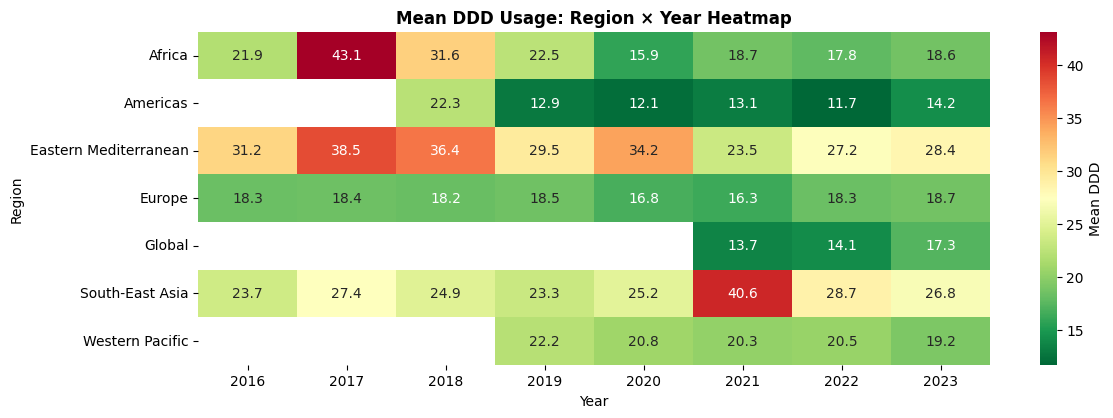

In [ ]:
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Correlation heatmap: Region vs Year trends
ax1 = fig.add_subplot(gs[0, :2])
sns.heatmap(region_year_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax1, cbar_kws={'label': 'Mean DDD'})
ax1.set_title('Mean DDD Usage: Region × Year Heatmap', fontsize=12, fontweight='bold')
ax1.set_ylabel('Region')
ax1.set_xlabel('Year')

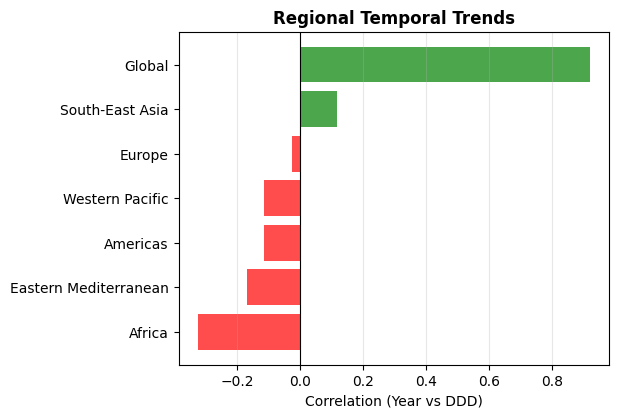

In [ ]:
# 2. Regional correlation trends
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
ax2 = fig.add_subplot(gs[0, 2])
region_corr_sorted = region_corr_df.sort_values('Correlation')
colors = ['red' if x < 0 else 'green' for x in region_corr_sorted['Correlation']]
ax2.barh(region_corr_sorted['Region'], region_corr_sorted['Correlation'], color=colors, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Correlation (Year vs DDD)')
ax2.set_title('Regional Temporal Trends', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

Text(0.5, 0, 'DDD per 1000 inhabitants per day')

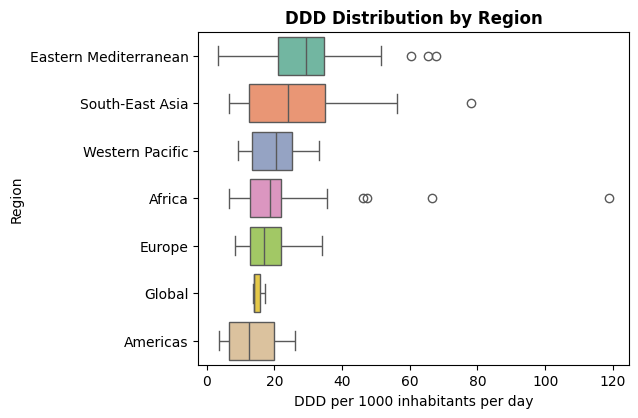

In [ ]:
# 3. Box plot: DDD by Region
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
ax3 = fig.add_subplot(gs[1, 0])
region_order = df_analysis.groupby('Region')['DDD_per_1000'].median().sort_values(ascending=False).index
sns.boxplot(data=df_analysis, y='Region', x='DDD_per_1000', order=region_order, ax=ax3, palette='Set2')
ax3.set_title('DDD Distribution by Region', fontsize=12, fontweight='bold')
ax3.set_xlabel('DDD per 1000 inhabitants per day')


Text(0.5, 0, 'DDD per 1000 inhabitants per day')

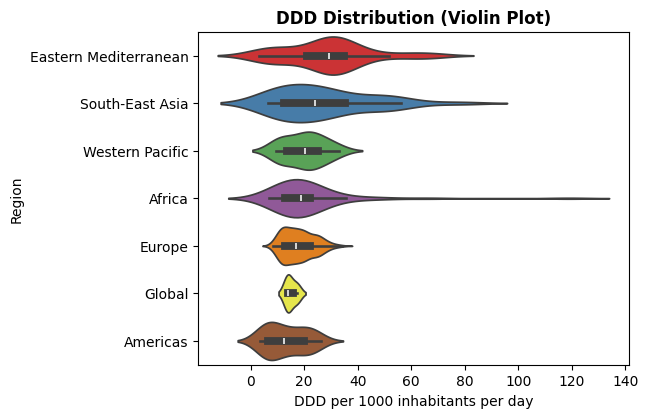

In [ ]:
# 4. Violin plot for better distribution visualization
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
ax4 = fig.add_subplot(gs[1, 1])
sns.violinplot(data=df_analysis, y='Region', x='DDD_per_1000', order=region_order, ax=ax4, palette='Set1')
ax4.set_title('DDD Distribution (Violin Plot)', fontsize=12, fontweight='bold')
ax4.set_xlabel('DDD per 1000 inhabitants per day')

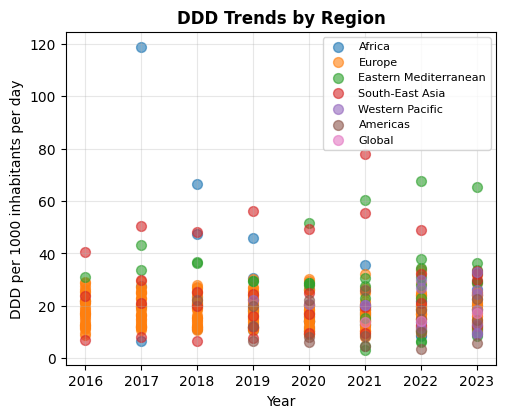

In [ ]:
# 5. Scatter plot with regional coloring
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
ax5 = fig.add_subplot(gs[1, 2])
for region in df_analysis['Region'].unique():
    region_data = df_analysis[df_analysis['Region'] == region]
    ax5.scatter(region_data['Year'], region_data['DDD_per_1000'], label=region, alpha=0.6, s=50)
ax5.set_xlabel('Year')
ax5.set_ylabel('DDD per 1000 inhabitants per day')
ax5.set_title('DDD Trends by Region', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, loc='best')
ax5.grid(True, alpha=0.3)

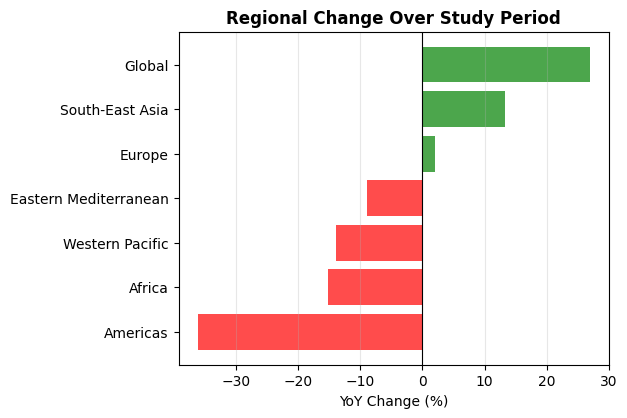

In [ ]:
# 6. Year-over-year change
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
ax6 = fig.add_subplot(gs[2, 0])
yoy_sorted = yoy_df.sort_values('YoY_Change_%', ascending=True)
colors_yoy = ['red' if x < 0 else 'green' for x in yoy_sorted['YoY_Change_%']]
ax6.barh(yoy_sorted['Region'], yoy_sorted['YoY_Change_%'], color=colors_yoy, alpha=0.7)
ax6.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax6.set_xlabel('YoY Change (%)')
ax6.set_title('Regional Change Over Study Period', fontsize=12, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

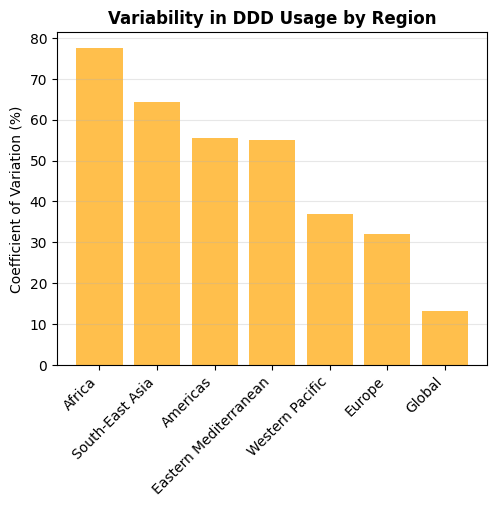

In [ ]:
# 7. Coefficient of Variation by Region
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
ax7 = fig.add_subplot(gs[2, 1])
cv_by_region = df_analysis.groupby('Region')['DDD_per_1000'].apply(
    lambda x: (x.std() / x.mean() * 100) if x.mean() != 0 else 0
).sort_values(ascending=False)
ax7.bar(range(len(cv_by_region)), cv_by_region.values, color='orange', alpha=0.7)
ax7.set_xticks(range(len(cv_by_region)))
ax7.set_xticklabels(cv_by_region.index, rotation=45, ha='right')
ax7.set_ylabel('Coefficient of Variation (%)')
ax7.set_title('Variability in DDD Usage by Region', fontsize=12, fontweight='bold')
ax7.grid(axis='y', alpha=0.3)

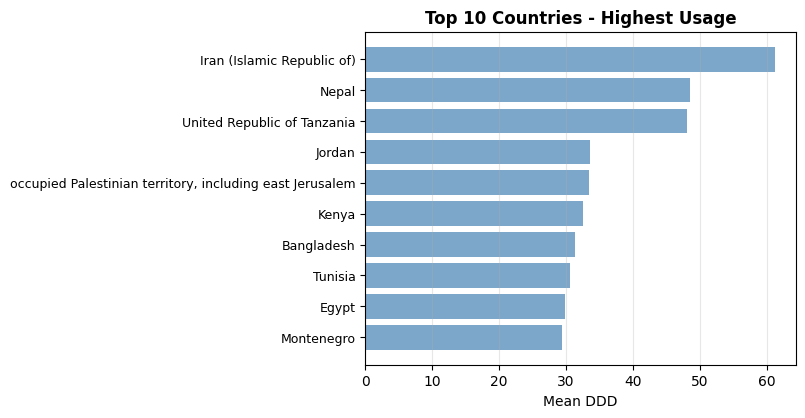

In [ ]:
# 8. Top 10 countries with highest average DDD
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
ax8 = fig.add_subplot(gs[2, 2])
top_countries = df_analysis.groupby('Country')['DDD_per_1000'].mean().nlargest(10).sort_values()
ax8.barh(range(len(top_countries)), top_countries.values, color='steelblue', alpha=0.7)
ax8.set_yticks(range(len(top_countries)))
ax8.set_yticklabels(top_countries.index, fontsize=9)
ax8.set_xlabel('Mean DDD')
ax8.set_title('Top 10 Countries - Highest Usage', fontsize=12, fontweight='bold')
ax8.grid(axis='x', alpha=0.3)
